In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from flax import struct

import matplotlib.pyplot as plt
from typing import Any, Callable, Optional, NamedTuple
from functools import partial

In [2]:
class Hyperplane(NamedTuple):
    normal: jax.Array
    intercept: jax.Array


def distance(plane: Hyperplane, point: jax.Array):
    return jnp.dot(plane.normal, point) - plane.intercept


def sample_normal(rng: jax.Array, features: jnp.int8, components: jnp.int8):
    rng_value, rng_idx = jax.random.split(rng)
    idxs = jax.random.randint(rng_idx, (components,), 0, features)
    values = jax.random.normal(rng_value, shape=(components,))
    normal = jnp.zeros((features,)).at[idxs].set(values)
    return normal / jnp.linalg.norm(normal)


def sample_intercept(rng: jax.Array, distances: jax.Array, mask: jax.Array):
    min_distance = jnp.where(mask, distances, jnp.inf).min()
    max_distance = jnp.where(mask, distances, -jnp.inf).max()
    intercept = jax.random.uniform(rng, (), minval=min_distance, maxval=max_distance)
    return intercept

In [3]:
def make_tree(rng: jax.Array, data: jax.Array, hyperplane_components: jnp.int8):
    points, features = data.shape
    max_depth = np.log2(points).astype(np.int8)
    nodes = 2 ** (max_depth) - 1
    rng_normal, rng_intercept = jax.random.split(rng)

    # presample normal vector independently for all nodes
    # precompute dot products between data points and normals
    # doing it this way technically requires more compute,
    # but it is much faster in practice due to vectorization + better memory access patterns
    sample_normal_batch = jax.vmap(sample_normal, in_axes=(0, None, None))
    normals = sample_normal_batch(
        jax.random.split(rng_normal, nodes), features, hyperplane_components
    )
    dot_prod_batch = jax.vmap(jax.vmap(jnp.dot, in_axes=(0, None)), in_axes=(None, 0))
    distances = dot_prod_batch(data, normals)

    # keep track of which nodes have been reached by each data point
    # splitting with a single point "forks" the path, so this needs to be
    # bool of shape (nodes, points) instead of int of shape (depth, points).
    # at the start, only the root node has been reached by all points
    reached = jnp.zeros((nodes, points), dtype=jnp.bool_)
    reached = reached.at[0, :].set(True)

    
    intercepts = jnp.zeros((nodes,))
    for depth, rng_layer in enumerate(jax.random.split(rng_intercept, max_depth)):
        layer_slice = jnp.arange(2**depth - 1, 2**depth + 2**depth - 1)

        intercepts=intercepts.at[layer_slice].set(
            jax.vmap(sample_intercept)(
            jax.random.split(rng_layer, 2**depth), distances[layer_slice], reached[layer_slice]
        )
        )

        reached = reached.at[2 * layer_slice + 1, :].set(
            reached[layer_slice] & (distances[layer_slice] >= intercepts[layer_slice, None])
        )
        reached = reached.at[2 * layer_slice + 2, :].set(
            reached[layer_slice] & (distances[layer_slice] <= intercepts[layer_slice, None])
        )
    return reached.sum(axis=1), normals, intercepts

In [4]:
rng = jax.random.PRNGKey(42)
data = jax.random.normal(rng, (16, 2))
reached, normals, intercepts = make_tree(rng, data, 2)

In [7]:
t = jax.jit(jax.vmap(make_tree, in_axes=(0,0,None)), static_argnums=(-1))
rng = jax.random.PRNGKey(42)
data = jax.random.normal(rng, (128, 32, 2))
rng = jax.random.split(rng, 128)
reached, normals, intercepts = t(rng, data, 2)
%timeit t(rng, data, 2)

2.15 ms ± 77 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


points: 32, nodes: 31


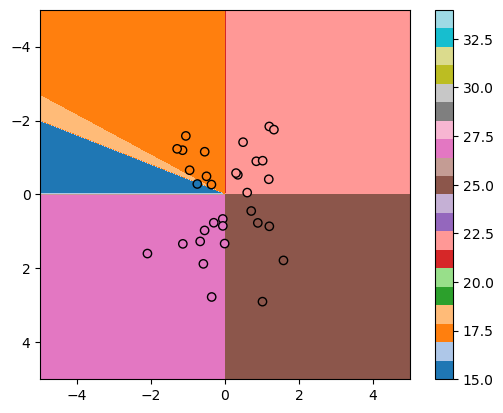

In [6]:
@jax.jit
def traverse_tree(x):
    return jax.lax.while_loop(
        lambda id: id < normals.shape[0]//2,
        lambda id: jax.lax.select(
            distance(Hyperplane(normals[id], intercepts[id]), x) >= 0, 2 * id + 1, 2 * id + 2
        ),
        0,
    )


rng = jax.random.PRNGKey(42)
data = jax.random.normal(rng, (32, 2))
reached, normals, intercepts = make_tree(rng, data, 2)

X, Y = jnp.meshgrid(jnp.linspace(-5, 5, 1000), jnp.linspace(-5, 5, 1000))
coord = jnp.stack([X.flatten(), Y.flatten()]).T
leaves = jax.vmap(traverse_tree)(coord)
leave_ids = sorted(jnp.unique(leaves))

tree_leaves = jax.vmap(traverse_tree)(data)
plt.imshow(leaves.reshape(1000, 1000), cmap="tab20", vmin=leave_ids[0], vmax=leave_ids[0]+19, extent=(-5, 5, 5, -5))
plt.colorbar()

plt.scatter(data[:, 0], data[:, 1], c=tree_leaves, edgecolors="k", cmap="tab20", vmin=leave_ids[0], vmax=leave_ids[0]+19)
print(f"points: {data.shape[0]}, nodes: {normals.shape[0]}")


In [8]:
intercepts

Array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)